# 07 — Cross-Cluster Comparison

Compare Pareto fronts from all 5 metallurgical families.
Which cluster achieves the best YS-UTS-El trade-off?

**Input**: `optimization_results/cluster_pareto.csv`  
**Output**: `figure/cross_cluster_pareto.pdf`

In [2]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

OPT_DIR = os.path.join('..', 'optimization_results')
FIGURE_DIR = os.path.join('..', 'figure'); os.makedirs(FIGURE_DIR, exist_ok=True)
SAVE_DPI = 600
colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e']

df = pd.read_csv(os.path.join(OPT_DIR, 'cluster_pareto.csv'))
# Use cluster_id for display if available, else fallback to cluster+1
if 'cluster_id' in df.columns:
    df['cid'] = df['cluster_id']
else:
    df['cid'] = df['cluster'] + 1
df['display_label'] = 'C' + df['cid'].astype(str) + ' ' + df['cluster_label']

print(f'{len(df)} Pareto solutions from {df["cid"].nunique()} clusters')
for c in sorted(df['cid'].unique()):
    sdf = df[df['cid']==c]
    label = sdf['cluster_label'].iloc[0]
    print(f'  C{c} ({label}): {len(sdf)} solutions, '
          f'YS={sdf["YS_pred"].min():.0f}-{sdf["YS_pred"].max():.0f}, '
          f'El={sdf["El_pred"].min():.1f}-{sdf["El_pred"].max():.1f}%')

235 Pareto solutions from 5 clusters
  C1 (Cu+Mg+Zn): 55 solutions, YS=352-572, El=5.1-22.7%
  C2 (Si+Cu+Mg): 49 solutions, YS=260-386, El=3.1-11.3%
  C3 (Cu+Mg+Zn): 40 solutions, YS=264-398, El=2.0-28.9%
  C4 (Si+Cu+Mg): 32 solutions, YS=323-372, El=2.0-10.2%
  C5 (Cu+Mg+Zn): 59 solutions, YS=359-562, El=5.6-28.7%


## 1. All-Cluster Pareto Overlay

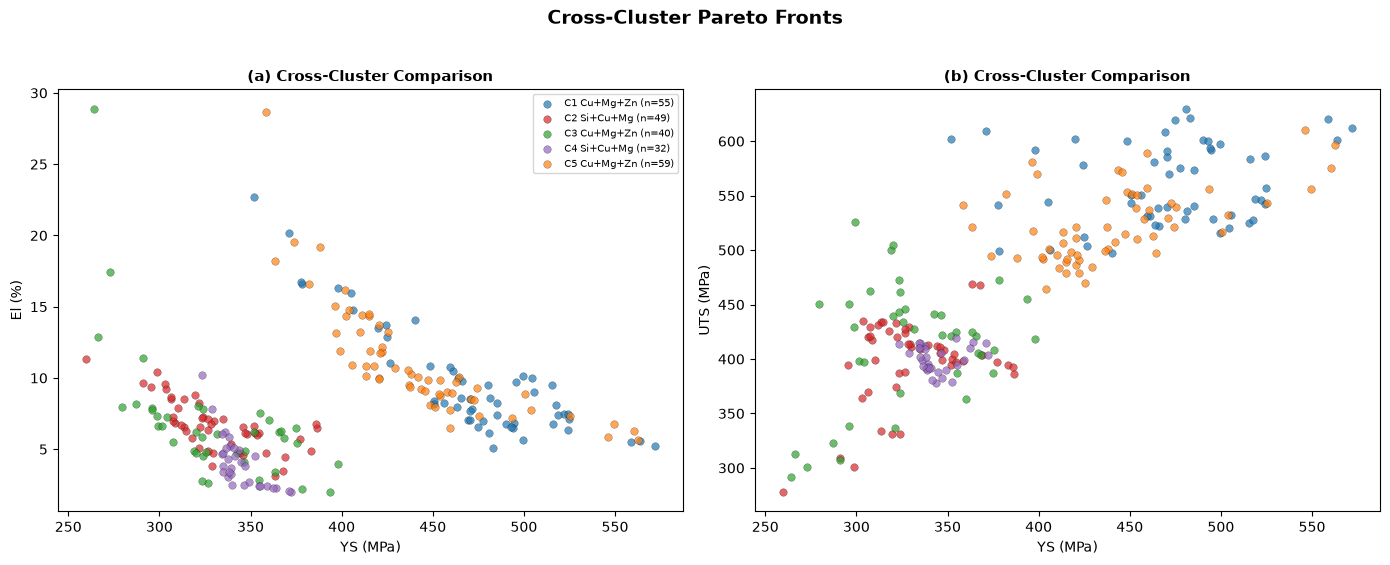

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i, (x, y, xl, yl) in enumerate([
    ('YS_pred','El_pred','YS (MPa)','El (%)'),
    ('YS_pred','UTS_pred','YS (MPa)','UTS (MPa)')]):
    ax = axes[i]
    for ci, c in enumerate(sorted(df['cid'].unique())):
        sdf = df[df['cid']==c]
        ax.scatter(sdf[x], sdf[y], c=colors[ci], s=30, alpha=0.7,
                 edgecolors='k', linewidth=0.2,
                 label=f'C{c} {sdf["cluster_label"].iloc[0]} (n={len(sdf)})')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'({chr(97+i)}) Cross-Cluster Comparison', fontsize=11, fontweight='bold')
    if i==0: ax.legend(fontsize=7)

fig.suptitle('Cross-Cluster Pareto Fronts', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'cross_cluster_pareto.pdf'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 2. Best per Cluster

Three representative points per cluster:
- **Max Strength**: highest YS on Pareto
- **Max Ductility**: highest El on Pareto  
- **Best Balance**: closest to utopia point (max YS, max UTS, max El) in normalized Euclidean distance

In [4]:
bb_list = []  # save BB data to avoid recomputing utopia distance

print(f'{"Cluster":<30} {"Max YS":>8} {"Max UTS":>9} {"Max El":>7}  |  {"Best Balance":>20}')
print('-' * 90)

for c in sorted(df['cid'].unique()):
    sdf = df[df['cid']==c]
    label = f'C{c} {sdf["cluster_label"].iloc[0]}'
    
    best_ys = sdf.loc[sdf['YS_pred'].idxmax()]
    best_uts = sdf.loc[sdf['UTS_pred'].idxmax()]
    best_el = sdf.loc[sdf['El_pred'].idxmax()]
    
    # Best Balance = closest to utopia (same method as N06)
    ys = sdf['YS_pred'].values
    uts = sdf['UTS_pred'].values
    el = sdf['El_pred'].values
    utopia = np.array([ys.max(), uts.max(), el.max()])
    nadir = np.array([ys.min(), uts.min(), el.min()])
    rng = np.where(utopia - nadir > 1e-6, utopia - nadir, 1.0)
    obj = np.column_stack([ys, uts, el])
    dist = np.sqrt(np.sum(((utopia - obj) / rng)**2, axis=1))
    bb = sdf.iloc[np.argmin(dist)]
    
    bb_list.append((label, bb['YS_pred'], bb['El_pred']))
    
    print(f'{label:<30} {best_ys["YS_pred"]:>8.0f} {best_uts["UTS_pred"]:>9.0f} '
          f'{best_el["El_pred"]:>6.1f}%  |  '
          f'{bb["YS_pred"]:.0f}/{bb["UTS_pred"]:.0f}/{bb["El_pred"]:.1f}%')

print(f'\nClusters sorted by Best Balance YS:')
for label, ys_val, el_val in sorted(bb_list, key=lambda x: x[1], reverse=True):
    print(f'  {label}: YS={ys_val:.0f}, El={el_val:.1f}%')

print('\nNext: 08_training_pareto_validation.ipynb')

Cluster                          Max YS   Max UTS  Max El  |          Best Balance
------------------------------------------------------------------------------------------
C1 Cu+Mg+Zn                         572       630   22.7%  |  420/602/13.5%
C2 Si+Cu+Mg                         386       469   11.3%  |  386/393/6.8%
C3 Cu+Mg+Zn                         398       526   28.9%  |  365/421/6.2%
C4 Si+Cu+Mg                         372       419   10.2%  |  334/410/6.1%
C5 Cu+Mg+Zn                         562       611   28.7%  |  546/611/5.9%

Clusters sorted by Best Balance YS:
  C5 Cu+Mg+Zn: YS=546, El=5.9%
  C1 Cu+Mg+Zn: YS=420, El=13.5%
  C2 Si+Cu+Mg: YS=386, El=6.8%
  C3 Cu+Mg+Zn: YS=365, El=6.2%
  C4 Si+Cu+Mg: YS=334, El=6.1%

Next: 08_training_pareto_validation.ipynb
